In [1]:
## Load libraries
import numpy as np
import sys
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.style.use('dark_background')
%matplotlib inline
from PIL import Image

import tensorflow as tf
tf.__version__

'2.14.0'

In [2]:
np.set_printoptions(precision=2)

---

Mount Google drive

---

In [3]:
## Mount Google drive folder if running in Colab
if('google.colab' in sys.modules):
    from google.colab import drive
    drive.mount('/content/drive', force_remount = True)
    # Change path below starting from /content/drive/MyDrive/Colab Notebooks/
    # depending on how data is organized inside your Colab Notebooks folder in
    # Google Drive
    DIR = '/content/drive/MyDrive/Colab Notebooks/MAHE/MSIS Coursework/EvenSem2024MAHE'
    DATA_DIR = DIR+'/Data/'
else:
    DATA_DIR = 'Data/'

---

**Load image**

<img src = 'https://drive.google.com/uc?id=1ZpG6qRKG-Ry9poVjvgJTtryOiFNwPWSI' width = '400'>

---

(337, 600)

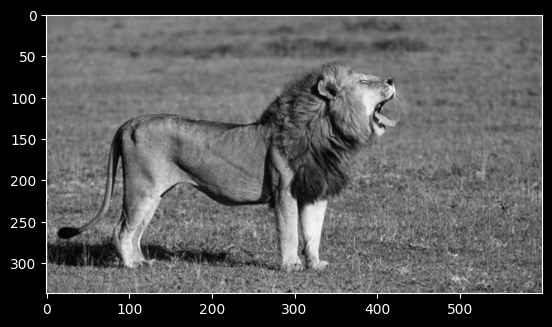

In [5]:
## Read image
FILENAME = DATA_DIR + 'lion_grayscale.jpg'
# Read image
img = Image.open(FILENAME)
plt.imshow(img, cmap = 'gray')
X = np.array(img)/1.0
X.shape

---

Define filters (also kernels because channel depth is 1 for a gray scale image)

---

In [7]:
W_smoothen = np.array([[
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
    ]])
print(W_smoothen.shape)

W_smoothen = np.transpose(W_smoothen, (1, 2, 0))
print(W_smoothen.shape)

(1, 3, 3)
(3, 3, 1)


In [14]:
W_guassian = np.array([[
    [1/16, 2/16, 1/16],
    [2/16, 4/16, 2/16],
    [1/16, 2/16, 1/16]
    ]])
print(W_guassian.shape)

W_guassian = np.transpose(W_guassian, (1, 2, 0))
print(W_smoothen.shape)

(1, 3, 3)
(3, 3, 1)


In [28]:
W_new = np.array([[
    [0, 1/4, 0],
    [1/4, -1, 1/4],
    [0,1/4, 0]
    ]])
print(W_new.shape)

W_new = np.transpose(W_new, (1, 2, 0))
print(W_new.shape)

(1, 3, 3)
(3, 3, 1)


In [ ]:
W_sharpen

In [ ]:
W_vertical = np.array([[
    [0, 1/4, 0],
    [1/4, -1, 1/4],
    [0,1/4, 0]
    ]])

---

Define convolution layer and initialize the kernel

---

In [29]:
layer = tf.keras.layers.Conv2D(
        filters = 1,
        kernel_size = [3, 3],
        strides = (1, 1),
        padding = 'same',
        kernel_initializer = tf.constant_initializer(W_new) 
    )

In [30]:
print(X.shape)
np.expand_dims(X, axis=(0, -1)).shape


(337, 600)


(1, 337, 600, 1)

---

Apply convolution layer and plot resulting output

---

input shape = (1, 337, 600, 1)
output shape = (1, 337, 600, 1)


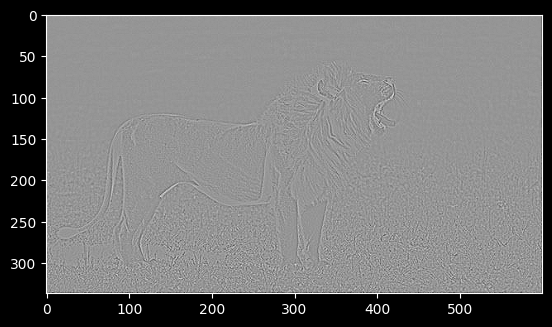

In [31]:
print(f'input shape = {np.expand_dims(X, axis = (0, -1)).shape}')
output = layer(np.expand_dims(X, axis = (0, -1)))
print(f'output shape = {output.shape}')

# Squeeze and plot the output
plt.imshow(tf.squeeze(output), cmap = 'gray');

In [32]:
tf.squeeze(output - tf.reduce_min(output))/(tf.reduce_max(output) - tf.reduce_min(output) * 255) 

<tf.Tensor: shape=(337, 600), dtype=float32, numpy=
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)>

---

In the following code segments, you will show that a convolution neuron learns about an input sample
1. channel-by-channel;
2. locally through the convolution operation.

The raw scores map $\mathbf{WX}$ calcuated by a single convolution neuron for a 3-channel input $\mathbf{X}$ is equal to $$\underbrace{\mathbf{W}_1}_{\text{kernel for channel-1}}\circledast\underbrace{\mathbf{X}_1}_\text{channel-1}+\underbrace{\mathbf{W}_2}_{\text{kernel for channel-2}}\circledast\underbrace{\mathbf{X}_2}_\text{channel-2}+\underbrace{\mathbf{W}_3}_{\text{kernel for channel-3}}\circledast\underbrace{\mathbf{X}_3}_\text{channel-3} +\underbrace{\mathbf{b}}_\text{bias of appropriate shape}.$$

---

In [ ]:
# An input image of shape 3 x 5 x 5 (channels x height x width)
X = tf.constant([
    [[0., 2, 0, 2, 1],
     [1, 1, 2, 0, 2],
     [0, 1, 0, 0, 1],
     [0, 2, 1, 2, 0],
     [2, 0, 0, 0, 2]
     ],
    [[2, 1, 0, 0, 1],
     [2, 2, 0, 2, 1],
     [0, 0, 0, 2, 0],
     [2, 2, 2, 0, 1],
     [0, 0, 1, 0, 2]],
    [[1, 2, 0, 0, 2],
     [2, 1, 1, 0, 1],
     [1, 2, 1, 0, 2],
     [0, 2, 1, 0, 1],
     [2, 2, 0, 1, 0]]
])
print(f'Original shape of X with channel as 0th axis = {X.shape}')

# Reshape input image into order (height x width x channels)
X = tf.transpose(X, (1, 2, 0))
print(f'Shape of X with channel as last axis = {X.shape}')

# Filter of shape 3 x 3 x 3 (height x width x kernels)
W = tf.constant([
    [[0., -1., -1],
     [0, 0, 0.],
     [-1, -1, -1]],
    [[1, 0, 1],
     [1., -1, -1],
     [1., 1., 0.]],
    [[1, -1, 0.],
     [-1, -1., 1],
     [0, 1., -1]]
]).numpy()
print(f'Shape of filter with kernels as the 0th axis = {W.shape}')

# bias value for the filter
b = 1

---

Calculate raw score as $\mathbf{WX}$ with a single convolution layer corresponding to a filter with 3 kernels and a bias. Use unit padding and stride = 2.

---

In [ ]:
## Define convolution layer
layer = tf.keras.layers.Conv2D(
        filters = 1,
        kernel_size = [3, 3],
        strides=(2, 2),
        padding = 'same',
        kernel_initializer = tf.constant_initializer(W),
        bias_initializer = tf.constant_initializer(b)
        )
# Apply convolution to the input sample to get the raw scores map
output = layer(np.expand_dims(X, axis = 0))
print(tf.squeeze(output))

---

Calculate raw scores map $\mathbf{WX}$ as $$\underbrace{\mathbf{W}_1}_{\text{kernel for channel-1}}\circledast\underbrace{\mathbf{X}_1}_\text{channel-1}+\underbrace{\mathbf{W}_2}_{\text{kernel for channel-2}}\circledast\underbrace{\mathbf{X}_2}_\text{channel-2}+\underbrace{\mathbf{W}_3}_{\text{kernel for channel-3}}\circledast\underbrace{\mathbf{X}_3}_\text{channel-3} +\underbrace{\mathbf{b}}_\text{bias of appropriate shape}$$ using a depthwise convolution layer corresponding to a filter with 3 kernels and a bias. Use unit padding and stride = 2.

---

In [ ]:
## Define depthwise convolution layer
layer_depthwise = tf.keras.layers.DepthwiseConv2D(
        kernel_size = [3, 3],
        strides=(2, 2),
        padding = 'same',
        depthwise_initializer = tf.constant_initializer(W)
    )
# Apply depthwise convolution to the input sample and add bias
# to get the raw scores map
output = layer_depthwise(np.expand_dims(X, axis = 0))
print(output.shape)
output = tf.reduce_sum(tf.squeeze(output), axis = -1) + b
print(output)

---

Calculate raw scores map $\mathbf{WX}$ as $$\underbrace{\mathbf{W}_1}_{\text{kernel for channel-1}}\circledast\underbrace{\mathbf{X}_1}_\text{channel-1}+\underbrace{\mathbf{W}_2}_{\text{kernel for channel-2}}\circledast\underbrace{\mathbf{X}_2}_\text{channel-2}+\underbrace{\mathbf{W}_3}_{\text{kernel for channel-3}}\circledast\underbrace{\mathbf{X}_3}_\text{channel-3} +\underbrace{\mathbf{b}}_\text{bias of appropriate shape}$$ using separate convolution layer for each channel and adding their output with the bias. Use unit padding and stride = 2.

---

In [ ]:
## Define channel-wise convolution layers
layer_channel0 = tf.keras.layers.Conv2D(
        filters = 1,
        kernel_size = [3, 3],
        strides=(2, 2),
        padding = 'same',
        kernel_initializer = tf.constant_initializer(np.expand_dims(W[:, :, 0], axis = 0))
        )

layer_channel1 = tf.keras.layers.Conv2D(
        filters = 1,
        kernel_size = [3, 3],
        strides=(2, 2),
        padding = 'same',
        kernel_initializer = tf.constant_initializer(np.expand_dims(W[:, :, 1], axis = 0))
        )

layer_channel2 = tf.keras.layers.Conv2D(
        filters = 1,
        kernel_size = [3, 3],
        strides=(2, 2),
        padding = 'same',
        kernel_initializer = tf.constant_initializer(np.expand_dims(W[:, :, 2], axis = 0))
        )

In [ ]:
## Perform channel-wise convolution and add along with bias to get the
## raw scores map
output0 = layer_channel0(np.expand_dims(X[:, :, 0], axis = (0, -1)))
output1 = layer_channel1(np.expand_dims(X[:, :, 1], axis = (0, -1)))
output2 = layer_channel2(np.expand_dims(X[:, :, 2], axis = (0, -1)))
output = output0 + output1 + output2 + b
print(tf.squeeze(output))

---

Define max-pooling layer.

---

In [ ]:
max_pool_2d = tf.keras.layers.MaxPooling2D(pool_size=(2, 2),
                                           strides = (1, 1),
                                           padding='valid')

---

Apply max-pooling to the output of the convolution layer

---

In [ ]:
tf.squeeze(max_pool_2d(output))

---

Load MNIST dataset.

Note that in TensorFlow, a typical representation of an image data set is a four-dimensional tensor with axes meanings [number of images, width, height, number of color channels]. In the MNIST dataset, we are reading grayscale images of shape 28 x 28 with only one color channel (a regular RGB color image has 3 color channels). So, we use np.expand_dims() to manually add the last dimension for the image data.

---

In [ ]:
# Load MNIST dataset and adjust shape

---

Define CNN Model

---

In [ ]:
class CNN(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.conv1 = tf.keras.layers.Conv2D(
            filters=32,
            kernel_size=[5, 5],
            padding='same',
            activation=tf.nn.relu
        )
        self.pool1 = tf.keras.layers.MaxPool2D(pool_size=[2, 2], strides=2)
        self.conv2 = tf.keras.layers.Conv2D(
            filters=64,
            kernel_size=[5, 5],
            padding='same',
            activation=tf.nn.relu
        )
        self.pool2 = tf.keras.layers.MaxPool2D(pool_size=[2, 2], strides=2)
        self.flatten = tf.keras.layers.Reshape(target_shape=(7 * 7 * 64,))
        self.dense1 = tf.keras.layers.Dense(units=1024, activation=tf.nn.relu)
        self.dense2 = tf.keras.layers.Dense(units=10)

    def call(self, inputs):
        x = self.conv1(inputs)                  # [batch_size, 28, 28, 32]
        x = self.pool1(x)                       # [batch_size, 14, 14, 32]
        x = self.conv2(x)                       # [batch_size, 14, 14, 64]
        x = self.pool2(x)                       # [batch_size, 7, 7, 64]
        x = self.flatten(x)                     # [batch_size, 7 * 7 * 64]
        x = self.dense1(x)                      # [batch_size, 1024]
        x = self.dense2(x)                      # [batch_size, 10]
        output = tf.nn.softmax(x)
        return output